In [39]:
import scanpy as sc
import pandas as pd
import scvi

from matplotlib import pyplot as plt
import numpy as np

In [40]:
# https://figshare.com/ndownloader/files/24539942
anndata = sc.read_h5ad("data/Lung_atlas_public.h5ad")
anndata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor'
    layers: 'counts'

In [41]:
anndata.raw = anndata  # keep full dimension safe
sc.pp.highly_variable_genes(
    anndata,
    flavor="cell_ranger",
    n_top_genes=2000,
    layer="counts",
    batch_key="batch",
    subset=True,
)
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg'
    layers: 'counts'

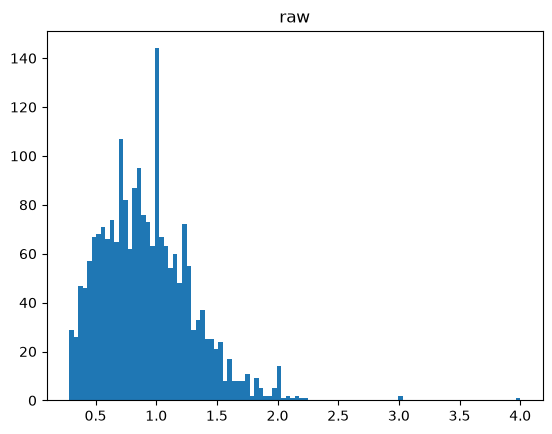

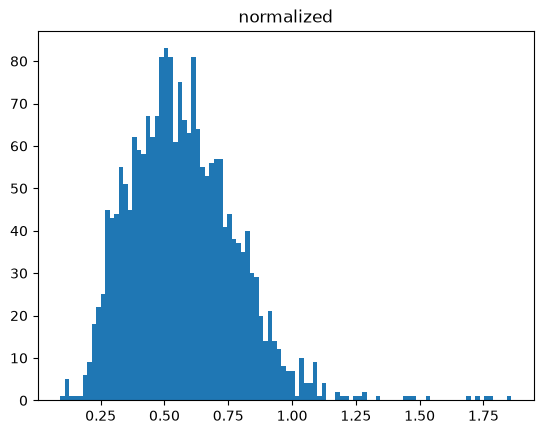

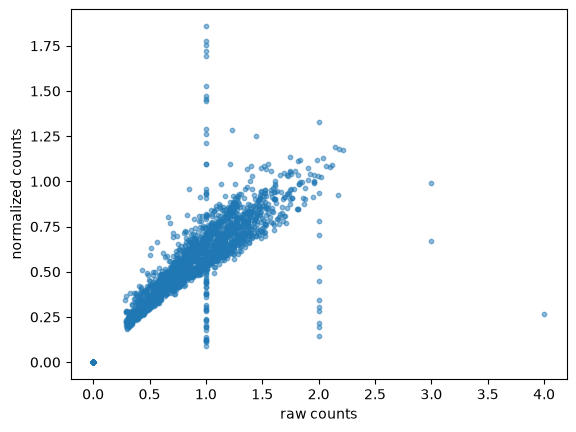

In [42]:
gene_id = 42
plt.title("raw")
plt.hist((anndata.layers["counts"][anndata.layers["counts"][:,gene_id].toarray().flatten()>0, gene_id].toarray().flatten()), bins=100)
plt.show()
plt.title("normalized")
plt.hist((anndata.X[anndata.X[:, gene_id].toarray().flatten()>0, gene_id].toarray().flatten()), bins=100)
plt.show()

plt.scatter(
    anndata.layers["counts"][:,gene_id].toarray().flatten(),
    anndata.X[:, gene_id].toarray().flatten(),
    alpha=.5, s=10
)
plt.xlabel("raw counts")
plt.ylabel("normalized counts")
plt.show()

In [43]:
anndata.obs.groupby("cell_type").size()

/tmp/ipykernel_104720/3276086893.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  anndata.obs.groupby("cell_type").size()


cell_type
B cell                  1353
Basal 1                 1972
Basal 2                 3072
Ciliated                3155
Dendritic cell          1367
Endothelium              988
Fibroblast               733
Ionocytes                 46
Lymphatic                341
Macrophage              7492
Mast cell                889
Neutrophil_CD14_high    1626
Neutrophils_IL1R2        472
Secretory               2459
T/NK cell               1797
Type 1                   424
Type 2                  4286
dtype: int64

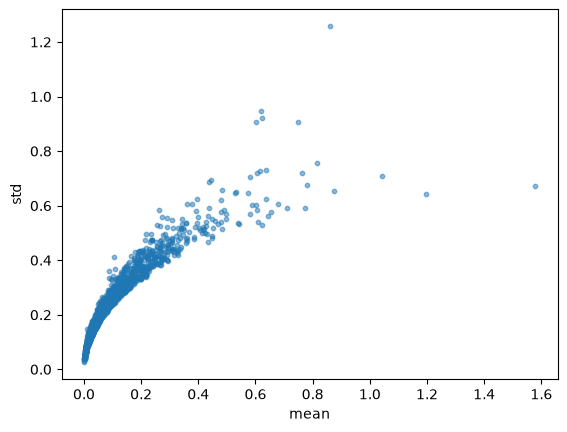

In [44]:
plt.scatter(
    anndata.X.toarray().mean(axis=0),
    anndata.X.toarray().std(axis=0),
    alpha=.5, s=10
)
plt.xlabel("mean")
plt.ylabel("std")
plt.show()

(array([1443., 6318., 1814., 3611., 9293., 6108.,  930.,  901., 1835.,
         219.]),
 array([ 18.04534912,  61.50917435, 104.97299957, 148.43682861,
        191.90065002, 235.36447144, 278.82830811, 322.29211426,
        365.75595093, 409.2197876 , 452.68359375]),
 <BarContainer object of 10 artists>)

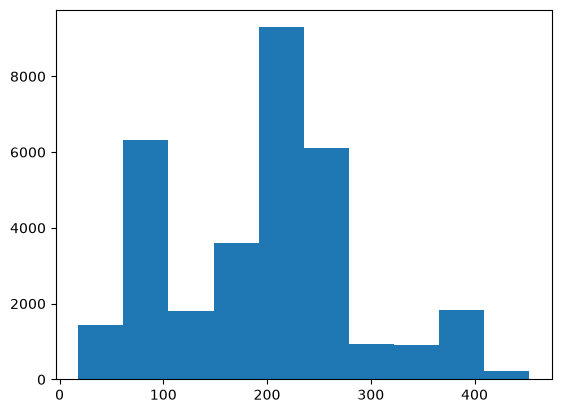

In [45]:
plt.hist(anndata.X.toarray().sum(axis=1))

In [46]:
sc.pp.normalize_per_cell(anndata, counts_per_cell_after=100)
sc.pp.pca(anndata, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(anndata)
sc.tl.umap(anndata)

/tmp/ipykernel_104720/2997299098.py:1: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(anndata, counts_per_cell_after=100)
/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


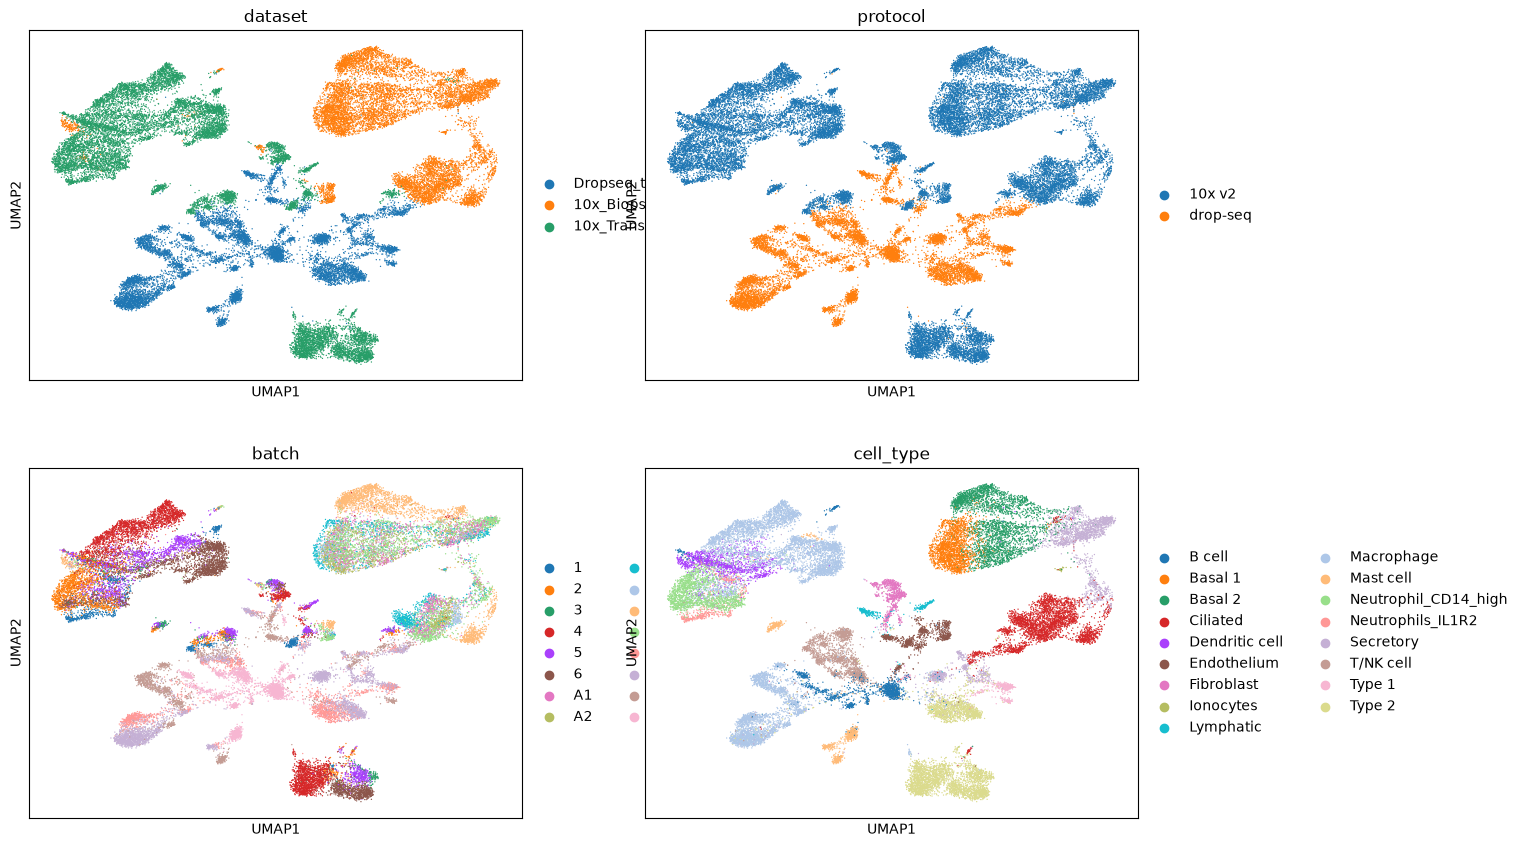

In [47]:
# original UMAP (without batch correction)
sc.pl.umap(anndata, color=["dataset", "protocol", "batch", "cell_type"], palette=sc.pl.palettes.vega_20_scanpy, ncols=2)

In [48]:
scvi.model.SCVI.setup_anndata(anndata, layer="counts", batch_key="batch")

/anaconda3/envs/bibola/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [49]:
scvi_model = scvi.model.SCVI(anndata, n_layers=2, n_latent=30, gene_likelihood="nb")
scvi_model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 30, n_layers: 2, dropout_rate: 0.1, dispersion: gene, gene_likelihood: nb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [50]:
scvi_model.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/anaconda3/envs/bibola/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Training:   0%|          | 0/246 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=246` reached.


In [51]:
SCVI_LATENT_KEY = "X_scVI"
anndata.obsm[SCVI_LATENT_KEY] = scvi_model.get_latent_representation()
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'n_counts', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'dataset_colors', 'protocol_colors', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'X_scVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [52]:
sc.pp.neighbors(anndata, use_rep=SCVI_LATENT_KEY, key_added="neighbors_scVI")
sc.tl.umap(anndata, neighbors_key="neighbors_scVI", key_added="umap_scVI")

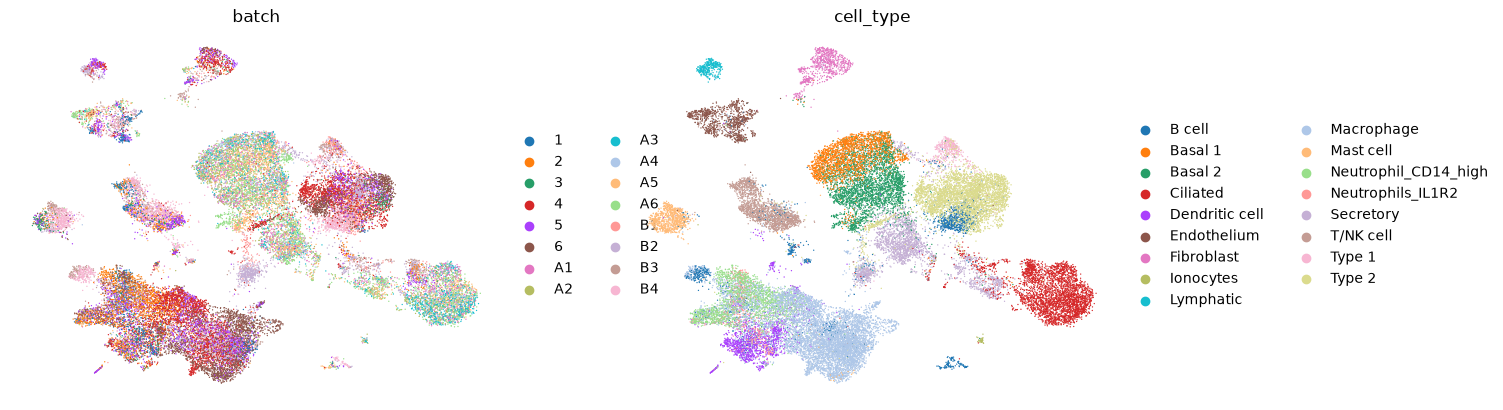

In [53]:
sc.pl.embedding(
    anndata,
    color=["batch", "cell_type"],
    basis="umap_scVI",
    frameon=False,
)

In [54]:
from bibola.model import ChunkIntegration

In [55]:
batch_correction_model = ChunkIntegration(
    in_channels=anndata.obsm["X_pca"].shape[1],
    hidden_channels=[128],
    out_channels=30,
    dropout=0.1,
    optimizer_kwargs={"lr": 1e-4}
)
batch_correction_model

ChunkIntegration(in_channels=50, hidden_channels=[128], out_channels=30, optimizer=Adam, not fitted)

In [56]:
batch_correction_model.fit(
    anndata.obsm["X_pca"], anndata.obs[["batch"]], epochs=2,
    print_every=1, k_inter=5, k_intra=100, norm=1,
    loss_weights={"abs_lisa_loss":1., "topology_loss": 1., "knn_loss": 1., "reconstruction_loss": 1.},
    n_chunks=10, verbose=True
)

  chunk 1/10 - total_loss=0.2984 (abs_lisa_loss=0.0422, topology_loss=-0.6523, knn_loss=-0.0713, reconstruction_loss=1.8749)
  chunk 2/10 - total_loss=0.2997 (abs_lisa_loss=0.0440, topology_loss=-0.6414, knn_loss=-0.0681, reconstruction_loss=1.8642)
  chunk 3/10 - total_loss=0.3002 (abs_lisa_loss=0.0423, topology_loss=-0.6354, knn_loss=-0.0641, reconstruction_loss=1.8579)
  chunk 4/10 - total_loss=0.2875 (abs_lisa_loss=0.0410, topology_loss=-0.6594, knn_loss=-0.0725, reconstruction_loss=1.8407)
  chunk 5/10 - total_loss=0.2837 (abs_lisa_loss=0.0410, topology_loss=-0.6537, knn_loss=-0.0774, reconstruction_loss=1.8250)
  chunk 6/10 - total_loss=0.2796 (abs_lisa_loss=0.0416, topology_loss=-0.6643, knn_loss=-0.0749, reconstruction_loss=1.8160)
  chunk 7/10 - total_loss=0.2789 (abs_lisa_loss=0.0404, topology_loss=-0.6622, knn_loss=-0.0747, reconstruction_loss=1.8123)
  chunk 8/10 - total_loss=0.2702 (abs_lisa_loss=0.0381, topology_loss=-0.6666, knn_loss=-0.0816, reconstruction_loss=1.7910)


In [57]:
batch_correction_model.loss_history

loss                                              loss_weights  \
  abs_lisa_loss topology_loss  knn_loss reconstruction_loss abs_lisa_loss   
0      0.041214     -0.654581 -0.073717            1.824419           1.0   
1      0.037476     -0.661127 -0.081209            1.721344           1.0   

                                              
  topology_loss knn_loss reconstruction_loss  
0           1.0      1.0                 1.0  
1           1.0      1.0                 1.0

In [58]:
anndata.obsm["X_corrected"] = batch_correction_model.transform(
    anndata.obsm["X_pca"], anndata.obs[["batch"]]
).detach().numpy()

from sklearn.decomposition import PCA

# we apply PCA to reduce the collinearity after the batch correction.
pca_model = PCA(n_components=batch_correction_model.out_channels)
anndata.obsm["X_corrected"] = pca_model.fit_transform(anndata.obsm["X_corrected"])
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'n_counts', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'dataset_colors', 'protocol_colors', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors_scVI', 'umap_scVI'
    obsm: 'X_pca', 'X_umap', 'X_scVI', 'umap_scVI', 'X_corrected'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'neighbors_scVI_distances', 'neighbors_scVI_connectivities'

In [59]:
sc.pp.neighbors(anndata, use_rep="X_corrected", key_added="neighbors_corrected")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected", key_added="umap_corrected")
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'n_counts', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'dataset_colors', 'protocol_colors', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors_scVI', 'umap_scVI', 'neighbors_corrected', 'umap_corrected'
    obsm: 'X_pca', 'X_umap', 'X_scVI', 'umap_scVI', 'X_corrected', 'umap_corrected'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'neighbors_scVI_distances', 'neighbors_scVI_connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities'

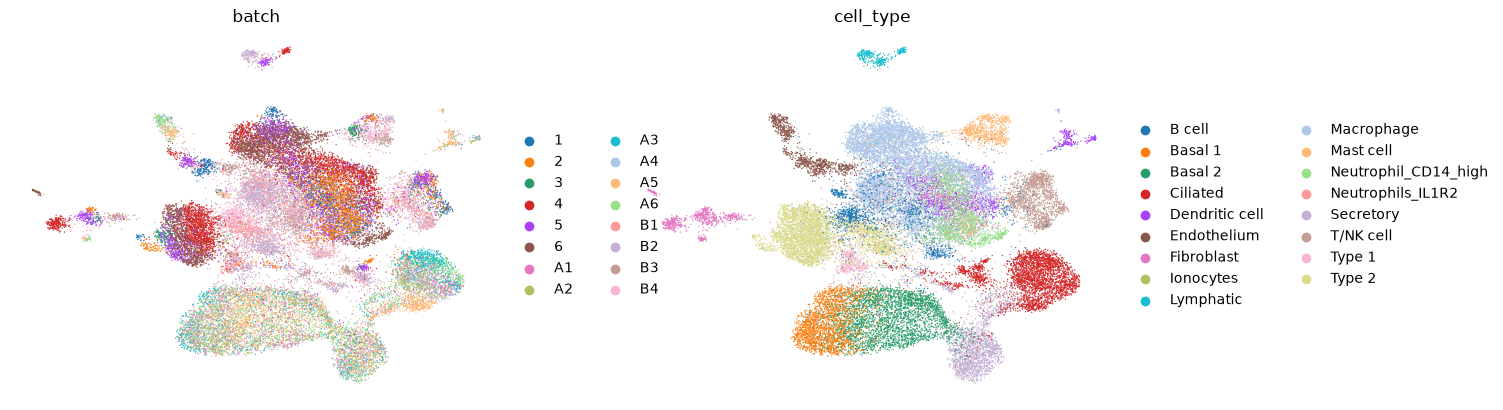

In [60]:
sc.pl.embedding(
    anndata,
    color=["batch", "cell_type"],
    basis="umap_corrected",
    frameon=False,
)
# UMAP after batch correction via bibola

In [61]:
from harmonypy import run_harmony
anndata.obsm["X_pca_harmony"] = run_harmony(anndata.obsm["X_pca"], anndata.obs, ["batch"]).Z_corr
anndata.obsm["X_pca_harmony"]

2026-08-13 20:11:21,778 - harmonypy - INFO - Running Harmony
2026-08-13 20:11:21,779 - harmonypy - INFO -   Parameters:
2026-08-13 20:11:21,779 - harmonypy - INFO -     max_iter_harmony: 10
2026-08-13 20:11:21,779 - harmonypy - INFO -     max_iter_kmeans: 4
2026-08-13 20:11:21,780 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-08-13 20:11:21,780 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-08-13 20:11:21,780 - harmonypy - INFO -     nclust: 100
2026-08-13 20:11:21,780 - harmonypy - INFO -     block_size: 0.05
2026-08-13 20:11:21,780 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-08-13 20:11:21,781 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-08-13 20:11:21,781 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-13 20:11:21,781 - harmonypy - INFO -     verbose: True
2026-08-13 20:11:21,781 - harmonypy - INFO -     random_state: 0
2026-08-13 20:11:21,782 - harmonypy - INFO -   Data: 50 PCs × 32472 cells
2026-08-

array([[ 3.31776714,  3.11805153, -0.88296324, ..., -0.16199899,
        -0.8525306 ,  1.69752526],
       [ 3.1681726 ,  2.62131166, -0.28560907, ..., -0.11384982,
         0.37504891, -0.28913081],
       [ 4.33096457,  4.41563225, -1.0854125 , ..., -0.17479056,
         0.1473812 ,  0.4297097 ],
       ...,
       [ 0.48687297, -2.878088  ,  0.47758514, ...,  0.04391256,
         0.13257238,  0.03049409],
       [ 0.52600467, -2.34116101,  0.24657525, ..., -0.05864985,
         0.10652032, -0.20316735],
       [ 0.56387615, -2.94539809,  0.529728  , ...,  0.05216533,
        -0.03862246,  0.06415308]], shape=(32472, 50))

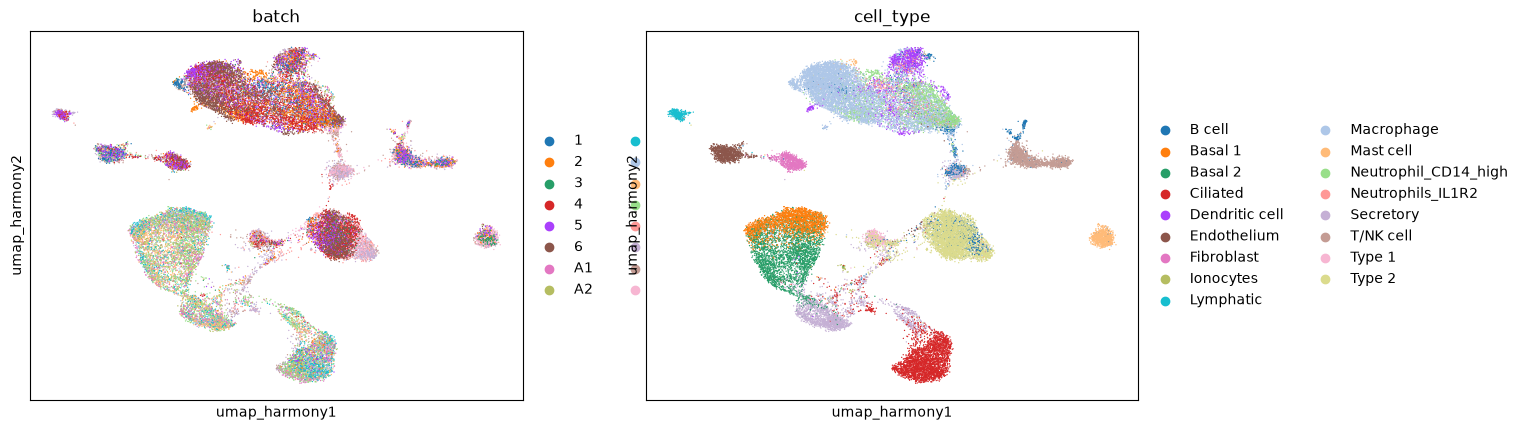

In [62]:
sc.pp.neighbors(anndata, use_rep="X_pca_harmony", key_added="neighbors_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_harmony", key_added="umap_harmony")
sc.pl.embedding(anndata, color=["batch", "cell_type"], palette=sc.pl.palettes.vega_20_scanpy, basis="umap_harmony")
# UMAP after batch correction via harmony

In [63]:
batch_correction_model = ChunkIntegration(
    in_channels=anndata.obsm["X_pca_harmony"].shape[1],
    hidden_channels=[128,],
    out_channels=30,
    dropout=0.1,
    optimizer_kwargs={"lr": 1e-4}
)
batch_correction_model

ChunkIntegration(in_channels=50, hidden_channels=[128], out_channels=30, optimizer=Adam, not fitted)

In [64]:
batch_correction_model.fit(
    anndata.obsm["X_pca_harmony"], anndata.obs[["batch"]], epochs=2,
    print_every=1, k_inter=5, k_intra=100, norm=1,
    loss_weights={"abs_lisa_loss":1., "topology_loss":1., "knn_loss":1., "reconstruction_loss": 1.},
    n_chunks=10, verbose=True
)

  chunk 1/10 - total_loss=0.3541 (abs_lisa_loss=0.0320, topology_loss=-0.6420, knn_loss=-0.0831, reconstruction_loss=2.1096)
  chunk 2/10 - total_loss=0.3489 (abs_lisa_loss=0.0306, topology_loss=-0.6423, knn_loss=-0.0856, reconstruction_loss=2.0929)
  chunk 3/10 - total_loss=0.3439 (abs_lisa_loss=0.0304, topology_loss=-0.6466, knn_loss=-0.0886, reconstruction_loss=2.0803)
  chunk 4/10 - total_loss=0.3442 (abs_lisa_loss=0.0339, topology_loss=-0.6403, knn_loss=-0.0820, reconstruction_loss=2.0653)
  chunk 5/10 - total_loss=0.3309 (abs_lisa_loss=0.0298, topology_loss=-0.6523, knn_loss=-0.0891, reconstruction_loss=2.0351)
  chunk 6/10 - total_loss=0.3430 (abs_lisa_loss=0.0336, topology_loss=-0.6358, knn_loss=-0.0725, reconstruction_loss=2.0467)
  chunk 7/10 - total_loss=0.3309 (abs_lisa_loss=0.0281, topology_loss=-0.6437, knn_loss=-0.0926, reconstruction_loss=2.0317)
  chunk 8/10 - total_loss=0.3308 (abs_lisa_loss=0.0322, topology_loss=-0.6298, knn_loss=-0.0805, reconstruction_loss=2.0011)


In [65]:
batch_correction_model.loss_history

loss                                              loss_weights  \
  abs_lisa_loss topology_loss  knn_loss reconstruction_loss abs_lisa_loss   
0      0.031316     -0.642355 -0.084460            2.044509           1.0   
1      0.029639     -0.648700 -0.090182            1.922128           1.0   

                                              
  topology_loss knn_loss reconstruction_loss  
0           1.0      1.0                 1.0  
1           1.0      1.0                 1.0

In [66]:
anndata.obsm["X_corrected_after_harmony"] = batch_correction_model.transform(
    anndata.obsm["X_pca_harmony"], anndata.obs[["batch"]]
).detach().numpy()

from sklearn.decomposition import PCA

pca_model = PCA(n_components=batch_correction_model.out_channels)
anndata.obsm["X_corrected_after_harmony"] = pca_model.fit_transform(anndata.obsm["X_corrected_after_harmony"])
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'n_counts', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'dataset_colors', 'protocol_colors', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors_scVI', 'umap_scVI', 'neighbors_corrected', 'umap_corrected', 'neighbors_harmony', 'umap_harmony'
    obsm: 'X_pca', 'X_umap', 'X_scVI', 'umap_scVI', 'X_corrected', 'umap_corrected', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'neighbors_scVI_distances', 'neighbors_scVI_connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_con

In [67]:
sc.pp.neighbors(anndata, use_rep="X_corrected_after_harmony", key_added="neighbors_corrected_after_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected_after_harmony", key_added="umap_corrected_after_harmony")
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'n_counts', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'dataset_colors', 'protocol_colors', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors_scVI', 'umap_scVI', 'neighbors_corrected', 'umap_corrected', 'neighbors_harmony', 'umap_harmony', 'neighbors_corrected_after_harmony', 'umap_corrected_after_harmony'
    obsm: 'X_pca', 'X_umap', 'X_scVI', 'umap_scVI', 'X_corrected', 'umap_corrected', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony', 'umap_corrected_after_harmony'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'neighbors_scVI_d

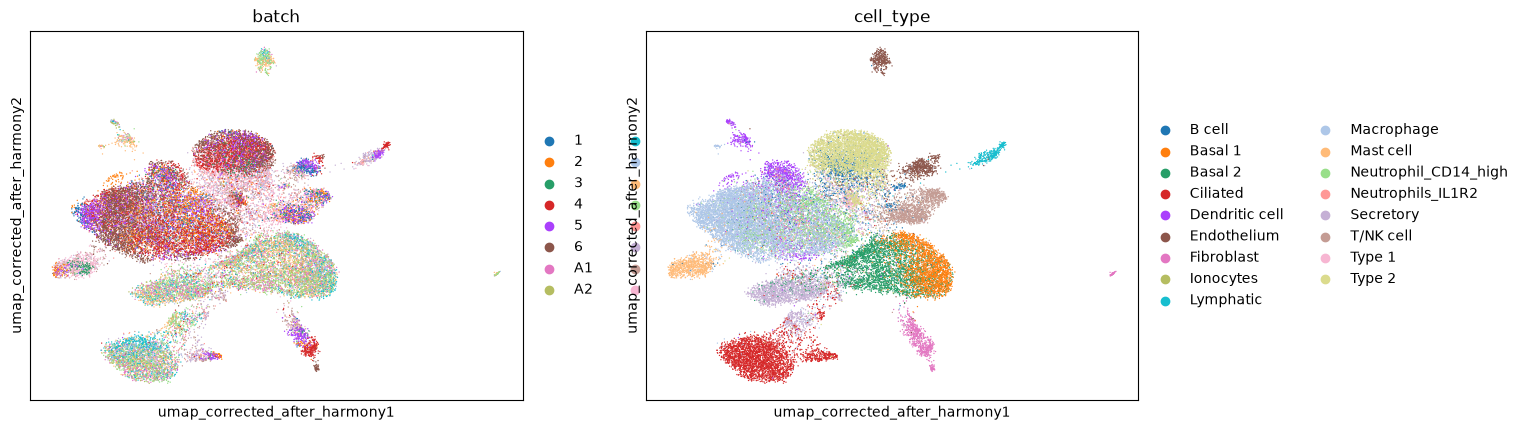

In [68]:
sc.pl.embedding(anndata, basis="umap_corrected_after_harmony", color=["batch", "cell_type"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after batch correction via bibola, starting from harmony

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


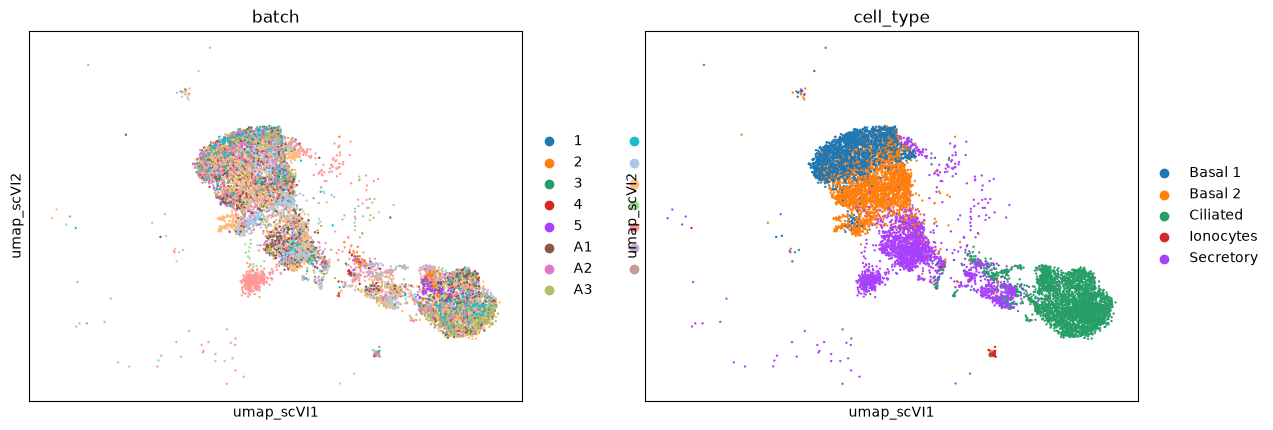

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


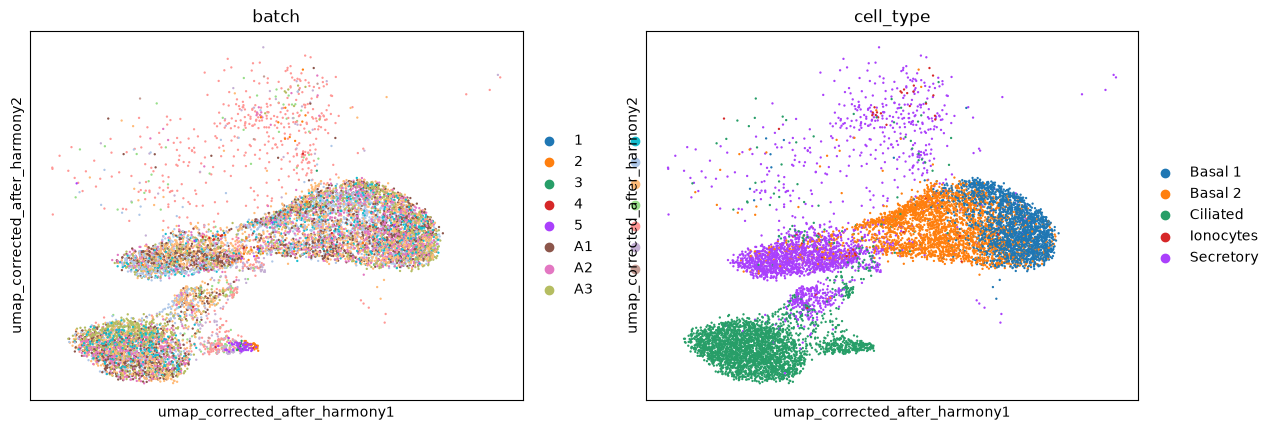

In [69]:
sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Basal 1", "Basal 2", "Secretory", "Ciliated", "Ionocytes"])],
    basis="umap_scVI",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Basal 1", "Basal 2", "Secretory", "Ciliated", "Ionocytes"])],
    basis="umap_corrected_after_harmony",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

# Basal
# ├── Basal 1
# ├── Basal 2
# │
# ├── Secretory
# │     └── Ciliated
# │
# └── Ionocytes
pass


/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


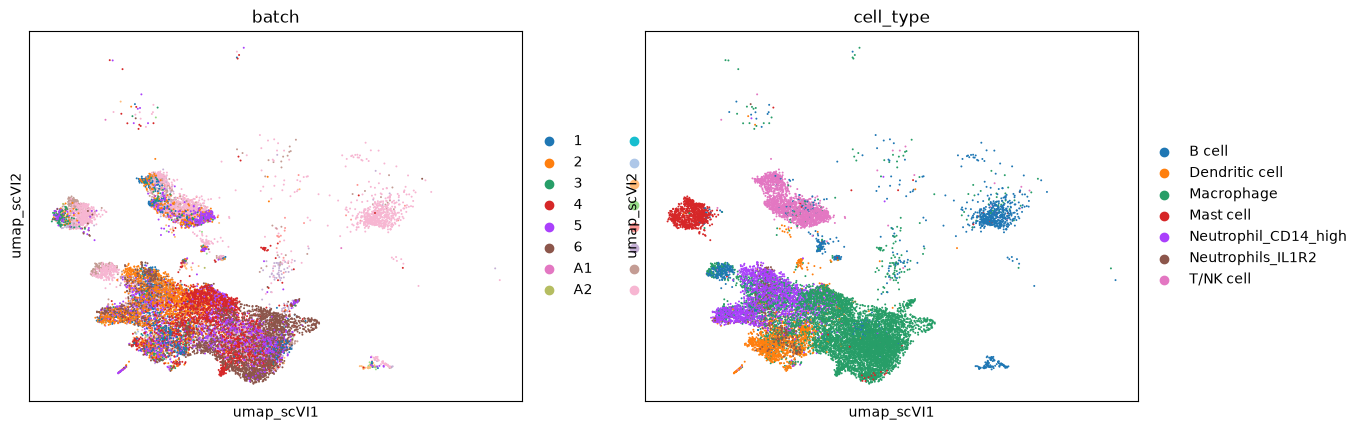

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


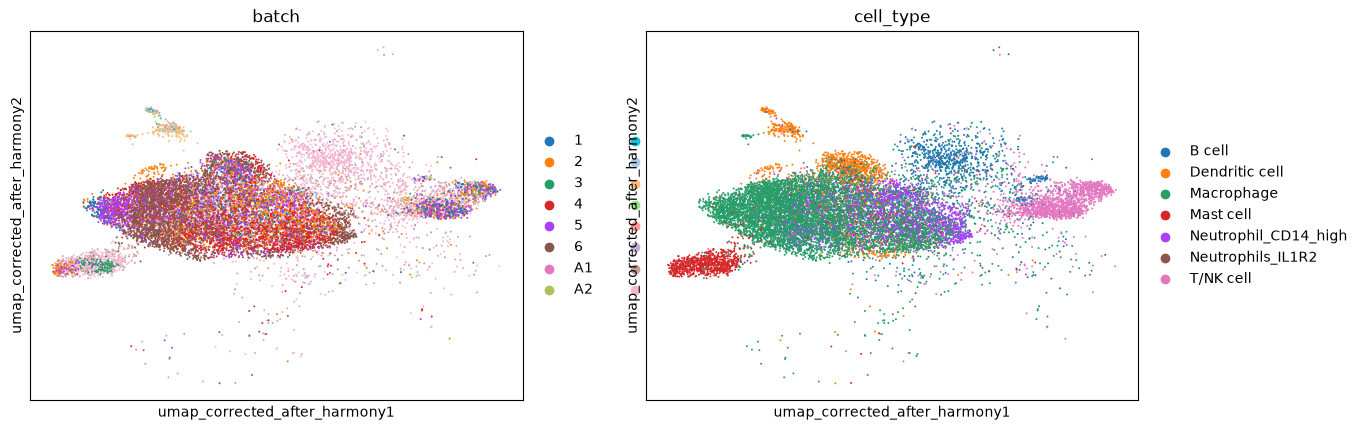

In [70]:
sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["B cell", "T/NK cell", "Neutrophils_IL1R2", "Neutrophil_CD14_high", "Macrophage", "Dendritic cell", "Mast cell"])],
    basis="umap_scVI",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["B cell", "T/NK cell", "Neutrophils_IL1R2", "Neutrophil_CD14_high", "Macrophage", "Dendritic cell", "Mast cell"])],
    basis="umap_corrected_after_harmony",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

# HSC
# ├── Lymphoid
# │     ├── B cell
# │     └── T/NK cell
# │
# └── Myeloid
#       ├── Neutrophils_IL1R2
#       ├── Neutrophil_CD14_high
#       ├── Macrophage
#       ├── Dendritic cell
#       └── Mast cell
pass


/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


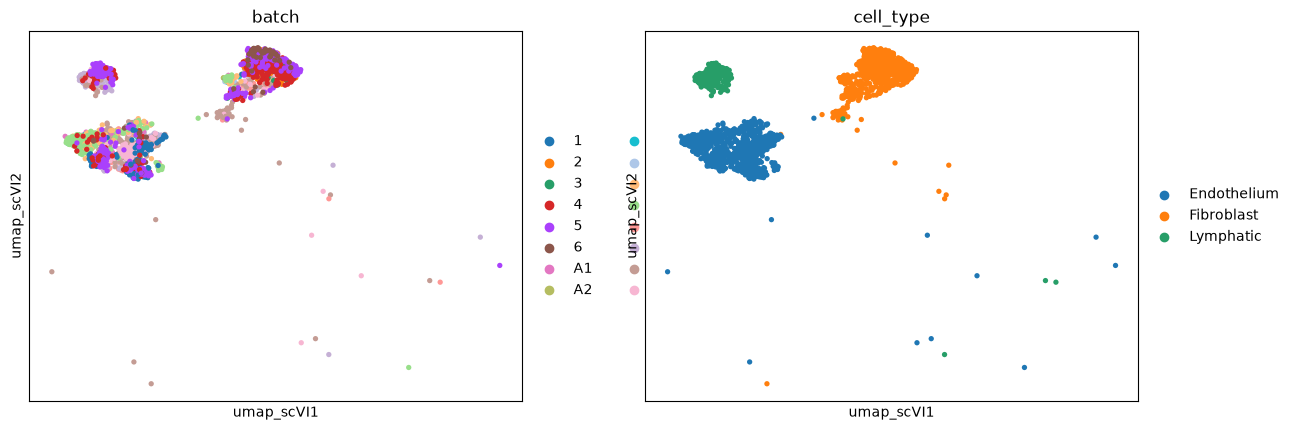

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


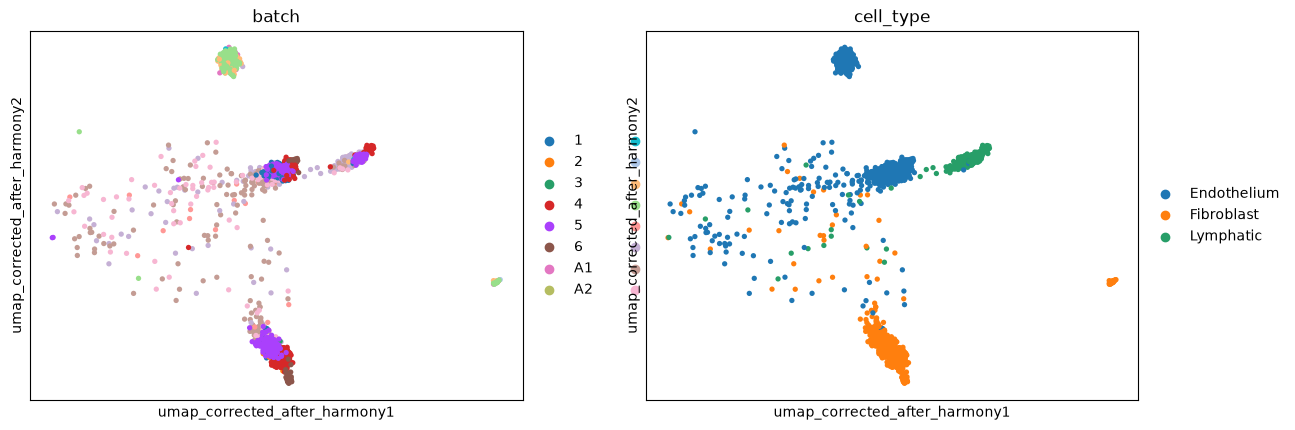

In [71]:
sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Fibroblast", "Endothelium", "Lymphatic"])],
    basis="umap_scVI",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Fibroblast", "Endothelium", "Lymphatic"])],
    basis="umap_corrected_after_harmony",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

# Mesenchymal progenitor
#       └── Fibroblast

# Endothelial progenitor
#       ├── Endothelium
#       └── Lymphatic endothelium
pass


/tmp/ipykernel_104720/2405925517.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_types = anndata.obs.groupby(["batch", "cell_type"]).size().unstack(fill_value=0)


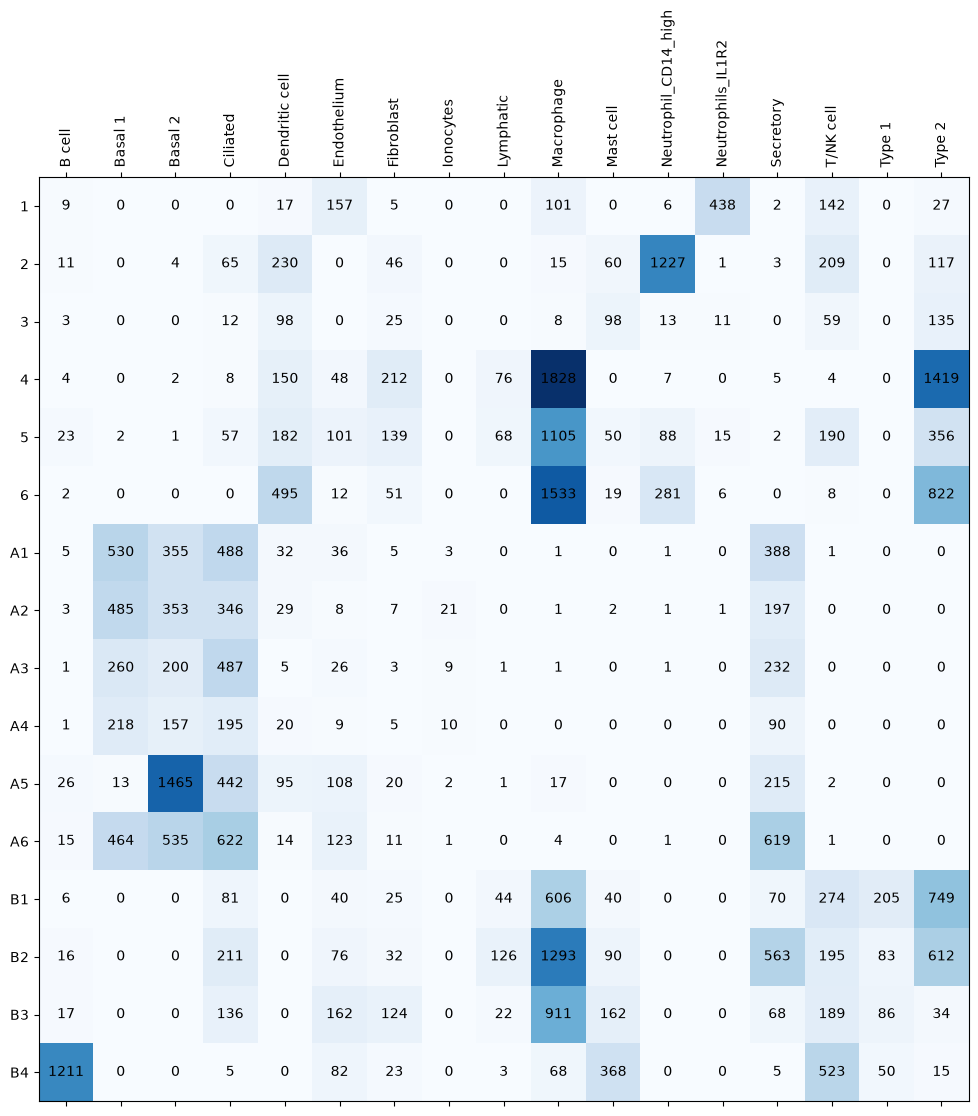

In [72]:
from matplotlib import pyplot as plt
import numpy as np

batch_types = anndata.obs.groupby(["batch", "cell_type"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 12))
plt.matshow(batch_types, cmap="Blues", aspect="auto", fignum=0)
for (i, j), val in np.ndenumerate(batch_types.values):
    plt.text(j, i, val, ha='center', va='center', color='black')
plt.xticks(range(len(batch_types.columns)), batch_types.columns, rotation=90)
plt.yticks(range(len(batch_types.index)), batch_types.index)
plt.show()